In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("predictive_maintenance_dataset.csv")

In [3]:
# =========================
#    Dataset Overview
# =========================
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe(include='all').T)

--- Dataset Shape ---
(124494, 12)

--- First 5 Rows ---
       date    device  failure    metric1  metric2  metric3  metric4  metric5  \
0  1/1/2015  S1F01085        0  215630672       55        0       52        6   
1  1/1/2015  S1F0166B        0   61370680        0        3        0        6   
2  1/1/2015  S1F01E6Y        0  173295968        0        0        0       12   
3  1/1/2015  S1F01JE0        0   79694024        0        0        0        6   
4  1/1/2015  S1F01R2B        0  135970480        0        0        0       15   

   metric6  metric7  metric8  metric9  
0   407438        0        0        7  
1   403174        0        0        0  
2   237394        0        0        0  
3   410186        0        0        0  
4   313173        0        0        3  

--- Data Types ---
date       object
device     object
failure     int64
metric1     int64
metric2     int64
metric3     int64
metric4     int64
metric5     int64
metric6     int64
metric7     int64
metric8     int6

In [4]:
# =========================
#    Identify Columns
# =========================
# Get all columns that contain numeric data
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Find the failure column (assuming it contains 'failure' or 'target')
failure_col = None
for col in df.columns:
    if 'failure' in col.lower() or 'target' in col.lower():
        failure_col = col
        break

if not failure_col:
    raise ValueError("No failure/target column found. Please update 'failure_col' manually.")

# Get a list of all metrics columns
metrics = [col for col in df.columns if "metric" in col]

# Set a clean plot style for better aesthetics
sns.set_style("whitegrid")

In [5]:
# =========================
# Visualization Section
# =========================


--- Failure Column Value Counts ---
failure
0    124388
1       106
Name: count, dtype: int64


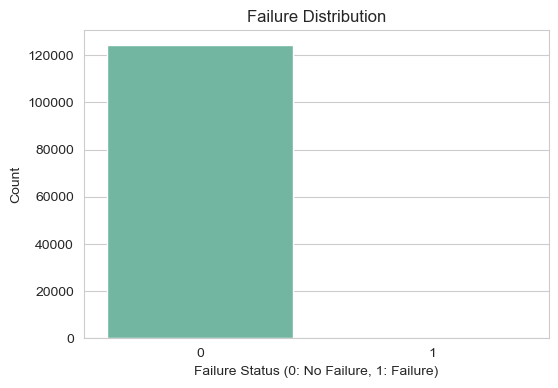

In [6]:
# --- 1. Failure Distribution ---
print("\n--- Failure Column Value Counts ---")
print(df[failure_col].value_counts())

plt.figure(figsize=(6, 4))
# Use 'Set2' palette, which provides distinct colors for the two classes
sns.countplot(x=failure_col, hue=failure_col, data=df, palette="Set2", legend=False)
plt.title("Failure Distribution")
plt.xlabel("Failure Status (0: No Failure, 1: Failure)")
plt.ylabel("Count")
plt.show()


--- Distribution of Metrics ---


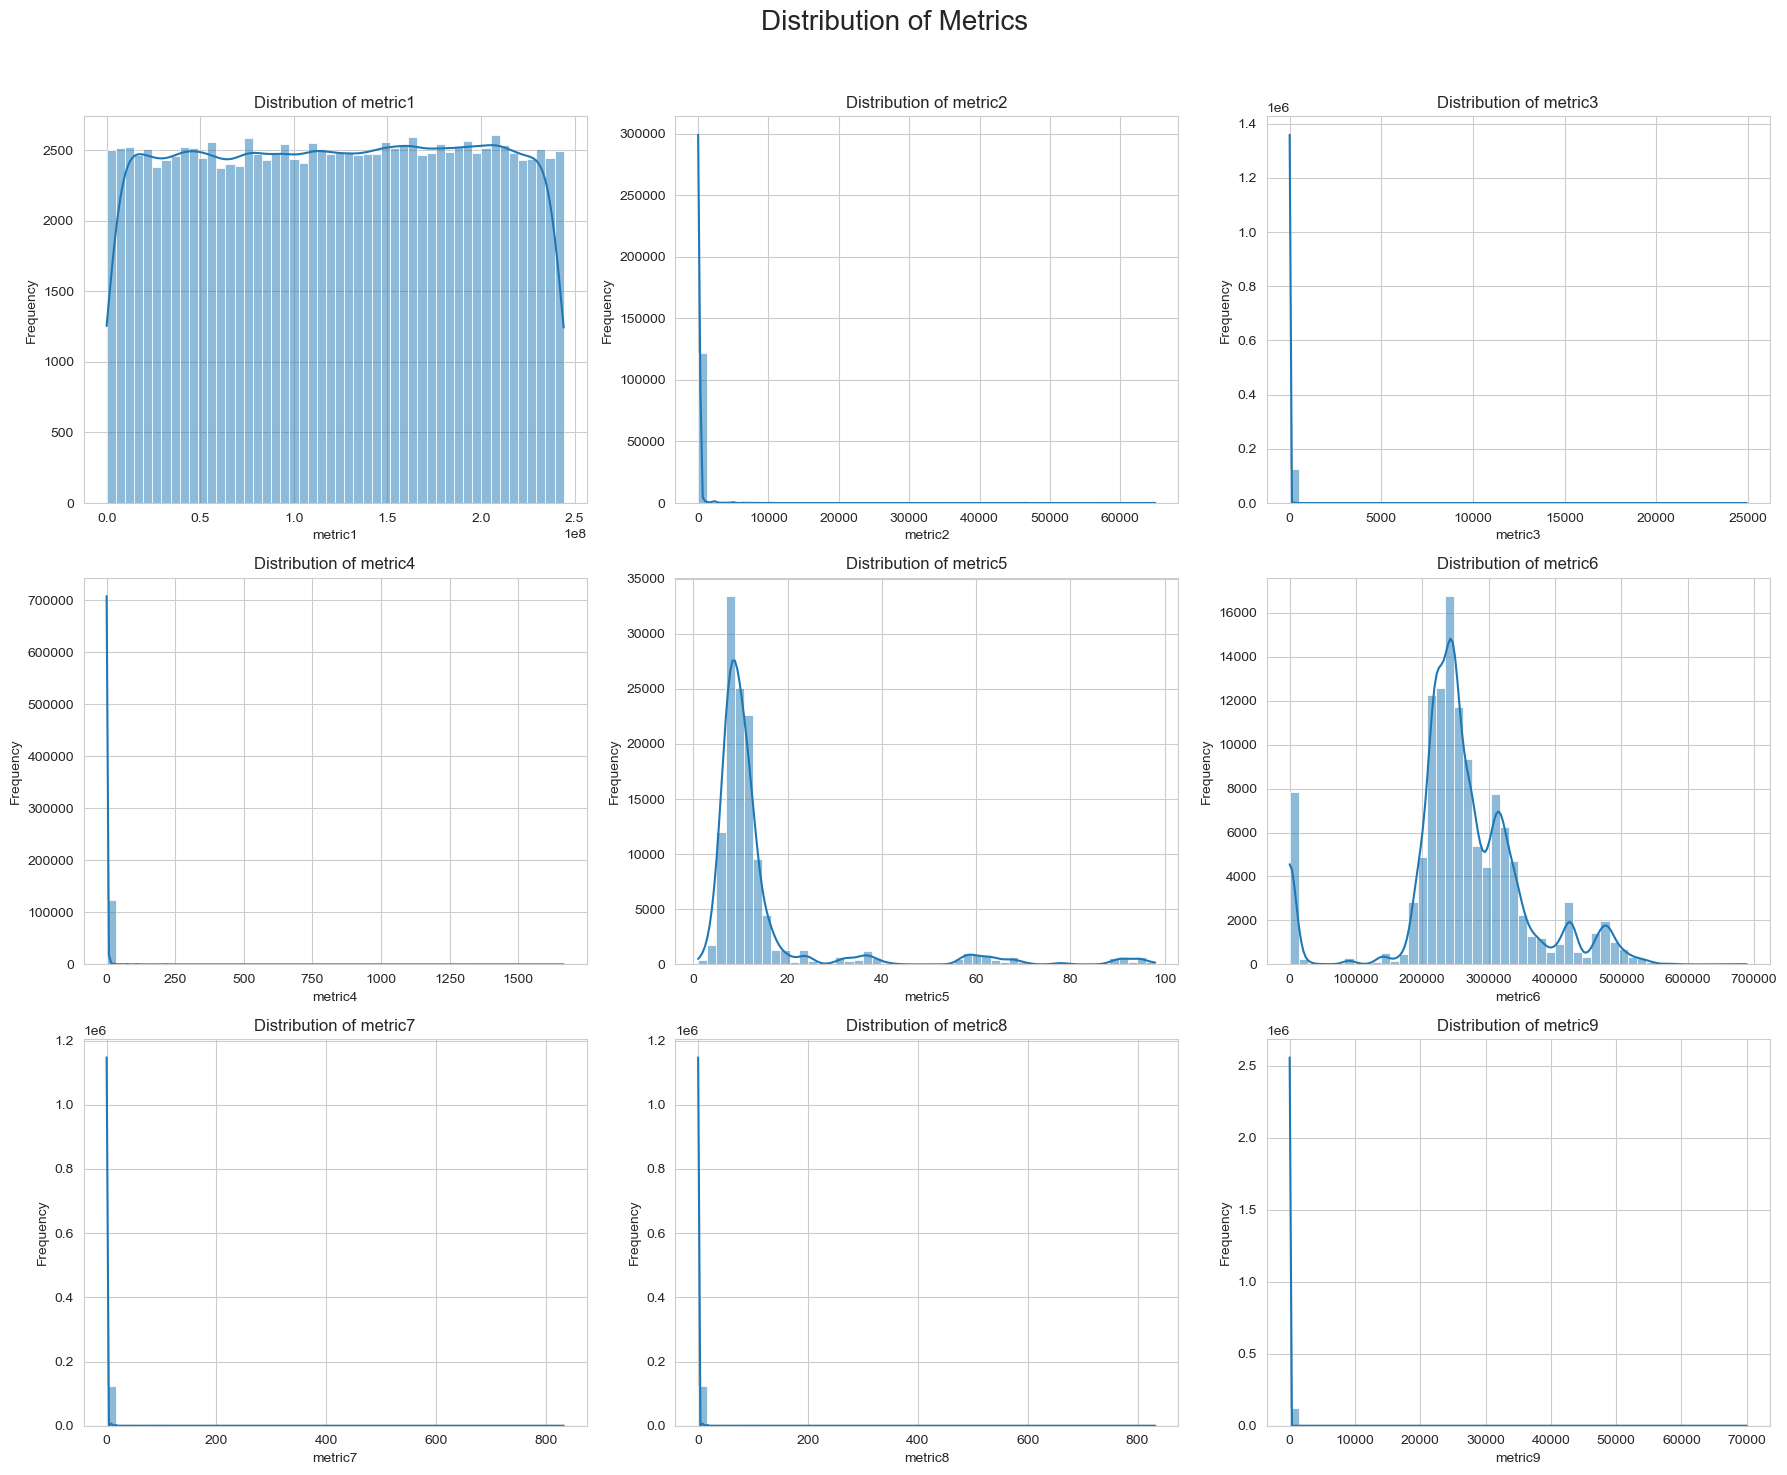

In [7]:
# --- 2. Distribution of Metrics ---
print("\n--- Distribution of Metrics ---")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle("Distribution of Metrics", fontsize=20)
for i, metric in enumerate(metrics):
    sns.histplot(df[metric], bins=50, kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f"Distribution of {metric}")
    axes[i//3, i%3].set_xlabel(metric)
    axes[i//3, i%3].set_ylabel("Frequency")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Visualizing Feature Correlation Heatmap...


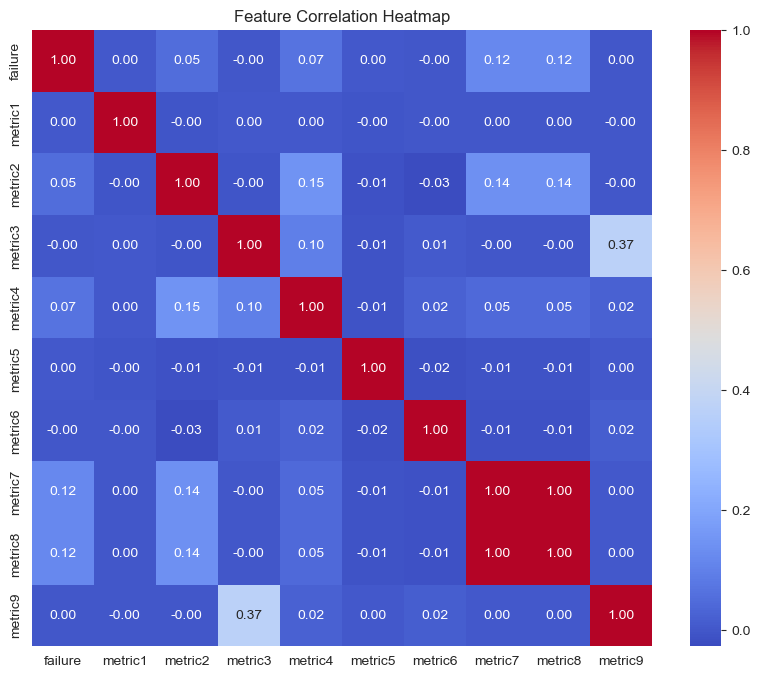

In [8]:
# --- 3. Correlation Heatmap ---
print("\nVisualizing Feature Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# 'coolwarm' cmap shows positive correlations in blue and negative in red
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


--- Temporal Trends of Metrics ---


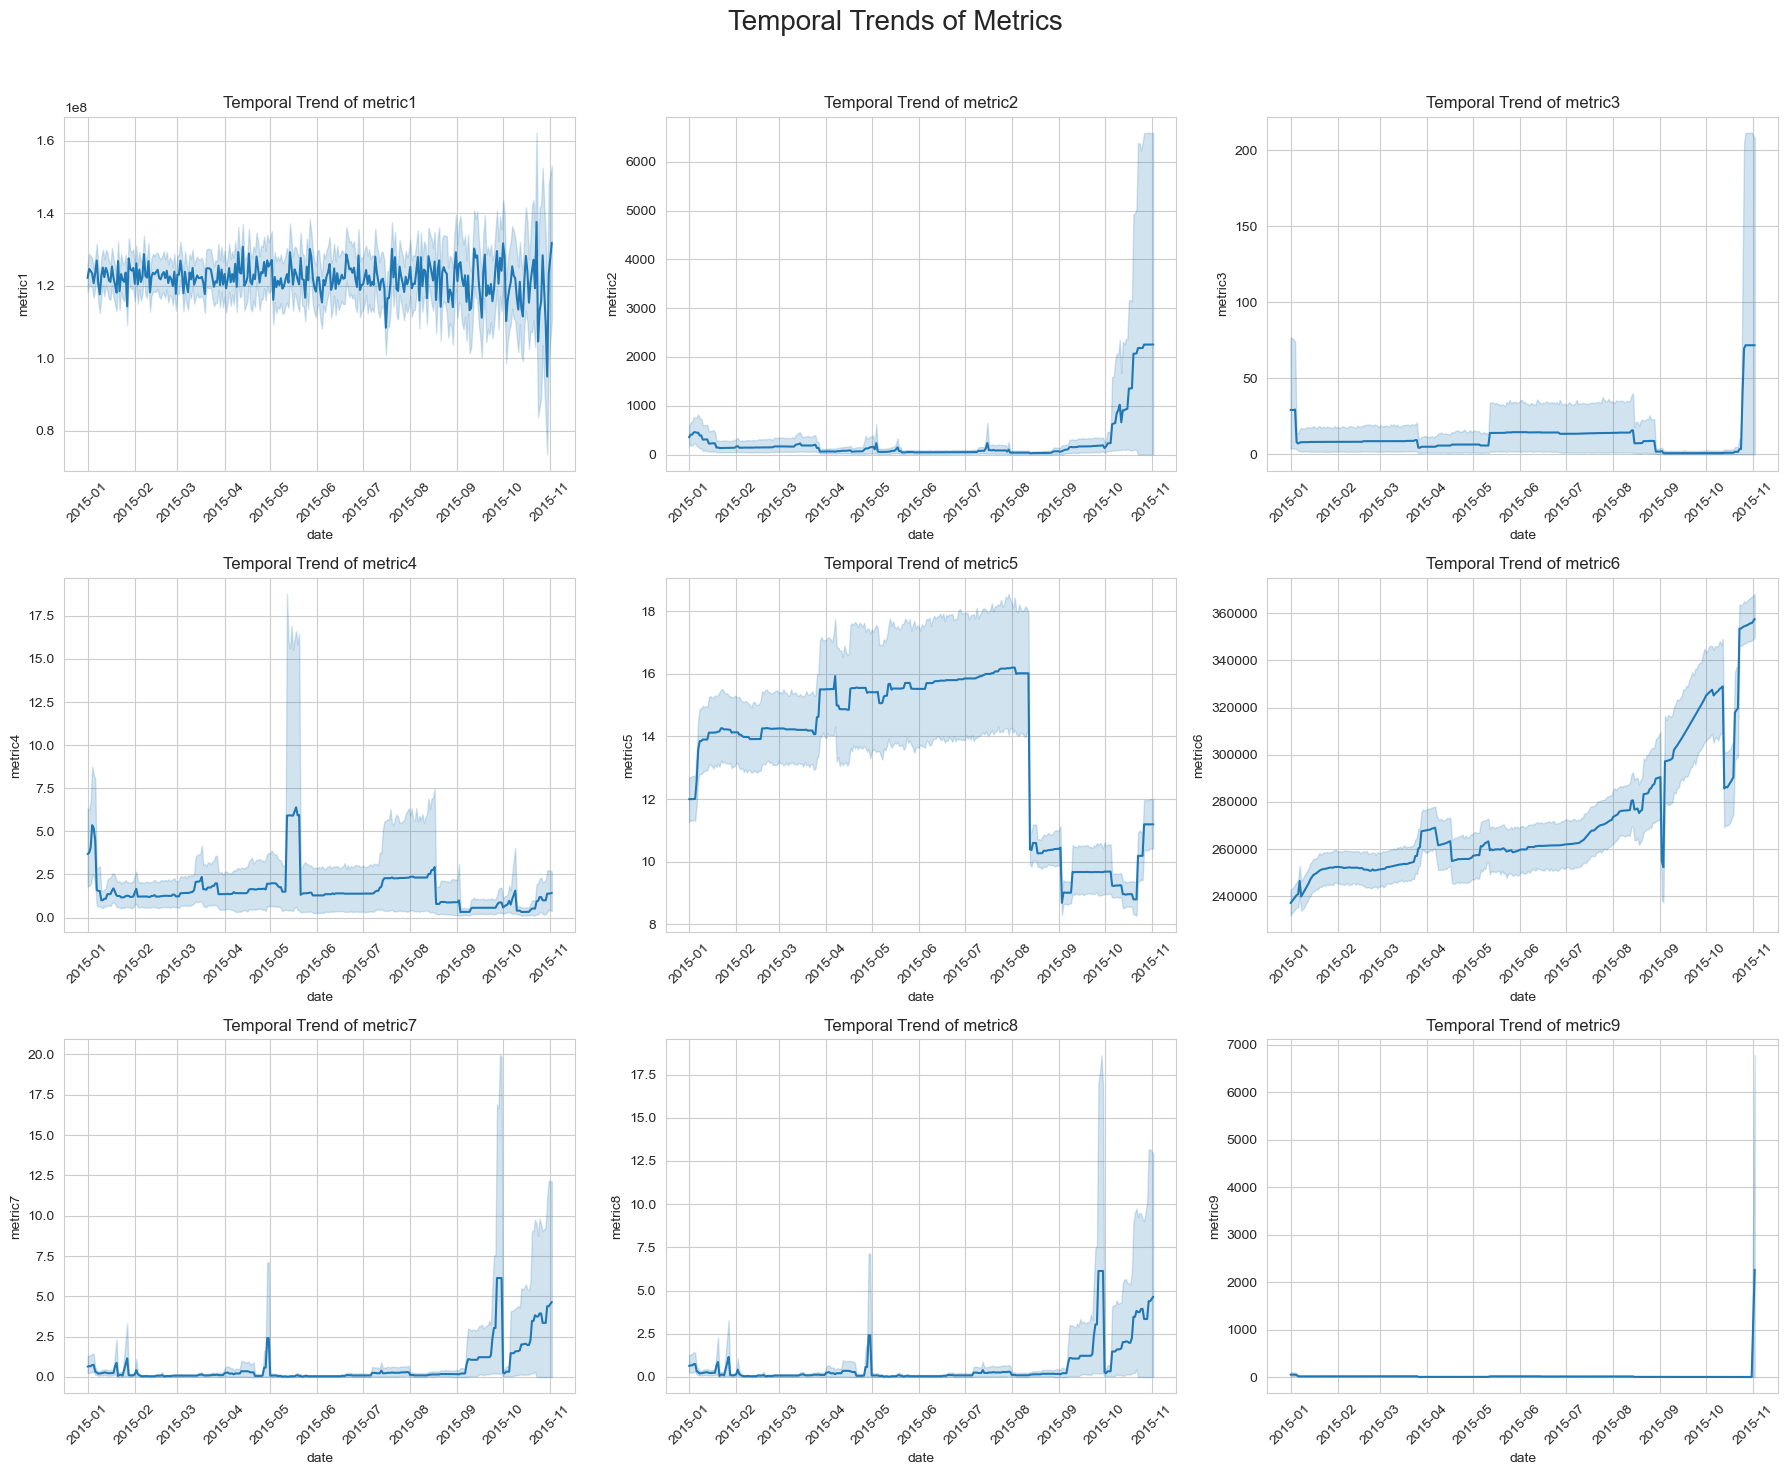

In [11]:
# =========================
# Temporal Trends of Metrics
# =========================
print("\n--- Temporal Trends of Metrics ---")
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle("Temporal Trends of Metrics", fontsize=20)
for i, metric in enumerate(metrics):
    sns.lineplot(x="date", y=metric, data=df, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f"Temporal Trend of {metric}")
    axes[i//3, i%3].tick_params(axis='x', rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Visualizing Temporal Trends of Metrics...


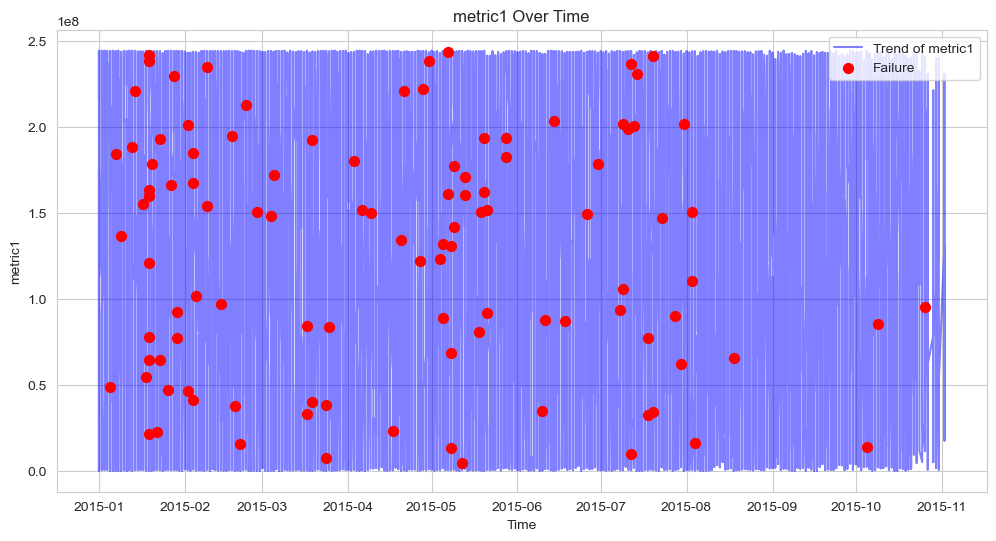

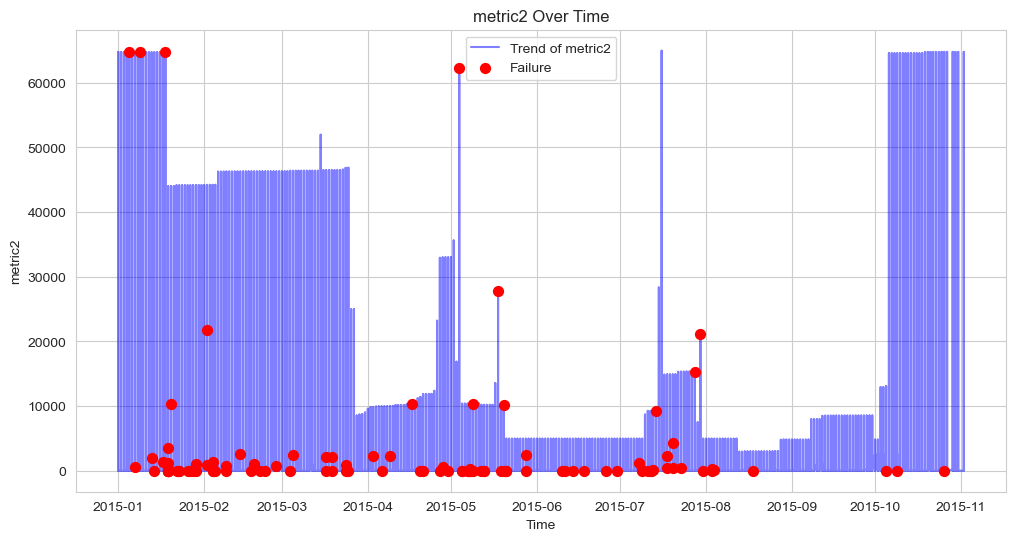

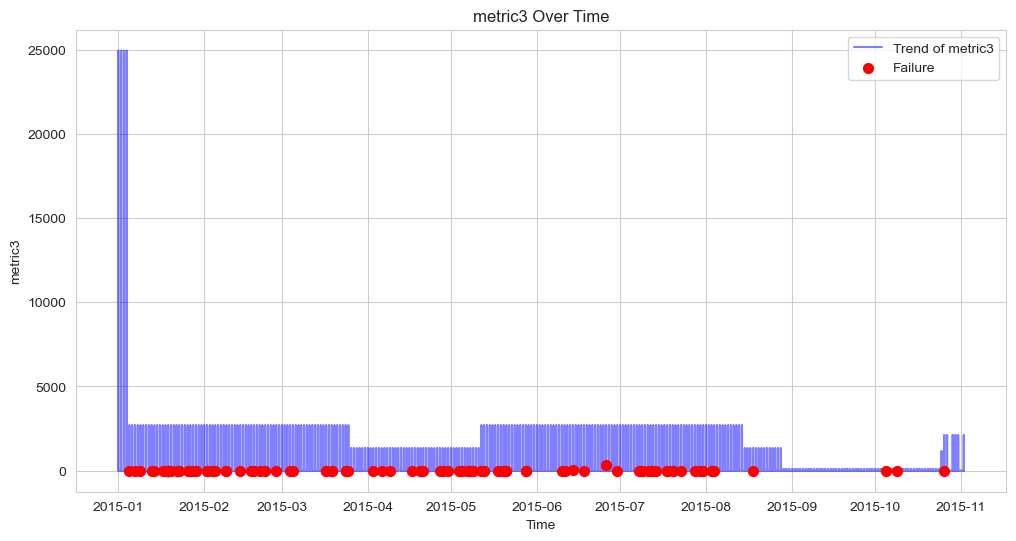

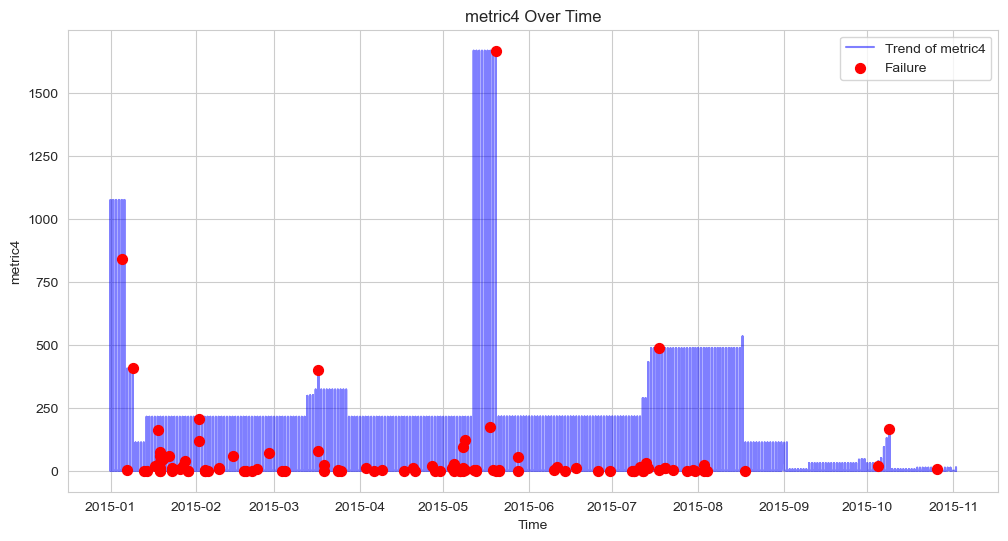

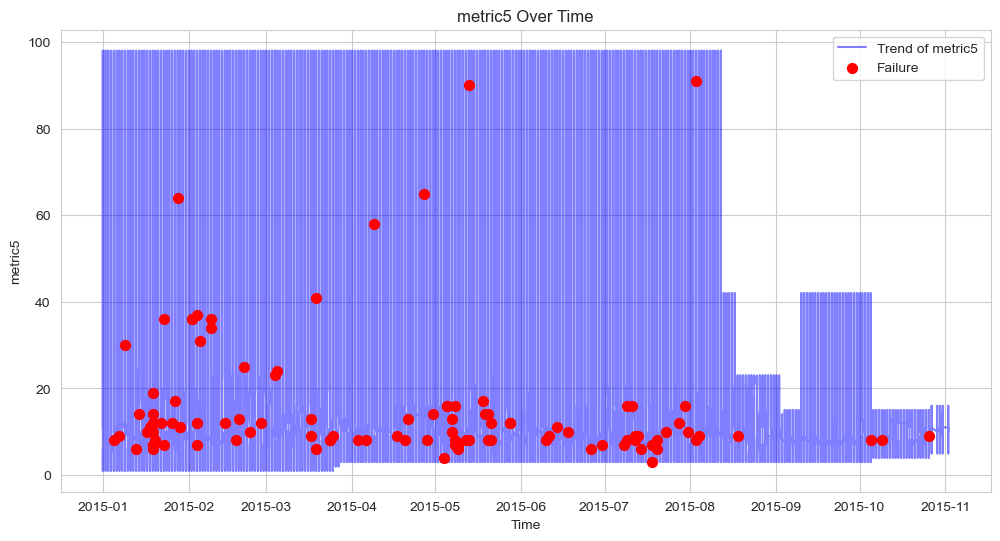

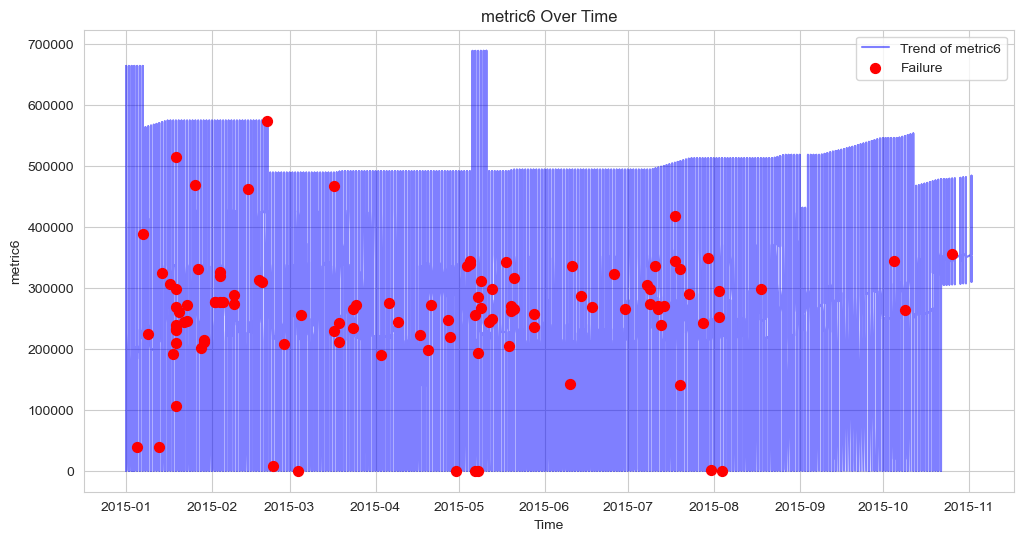

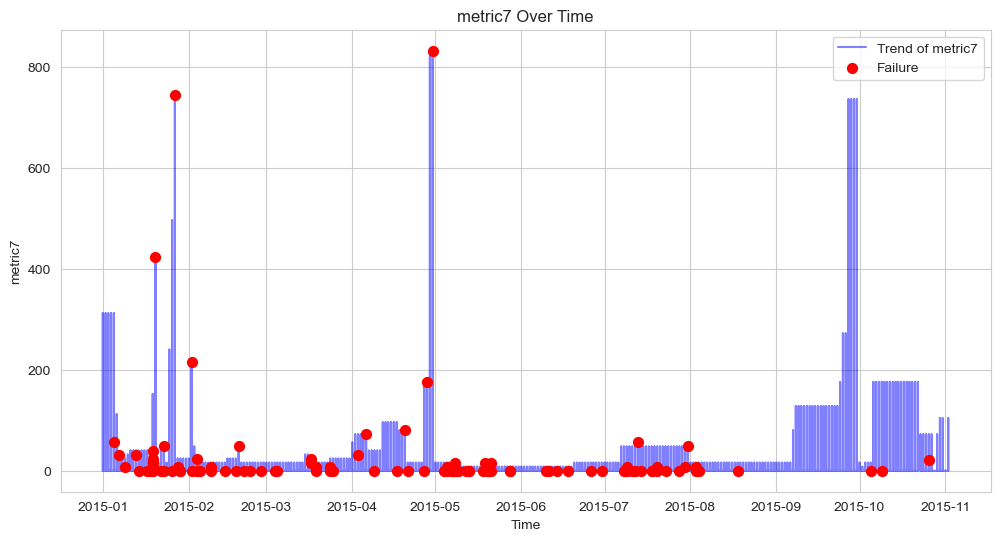

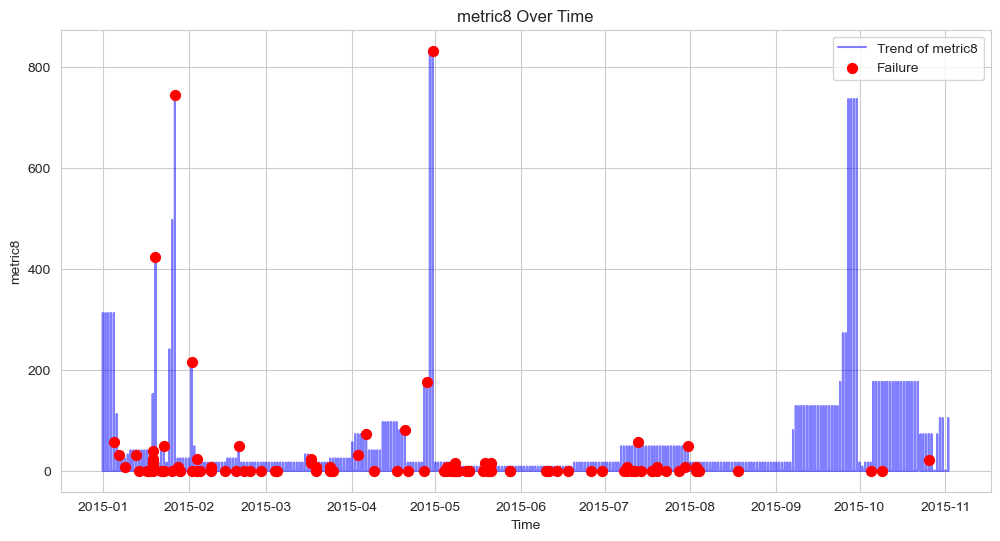

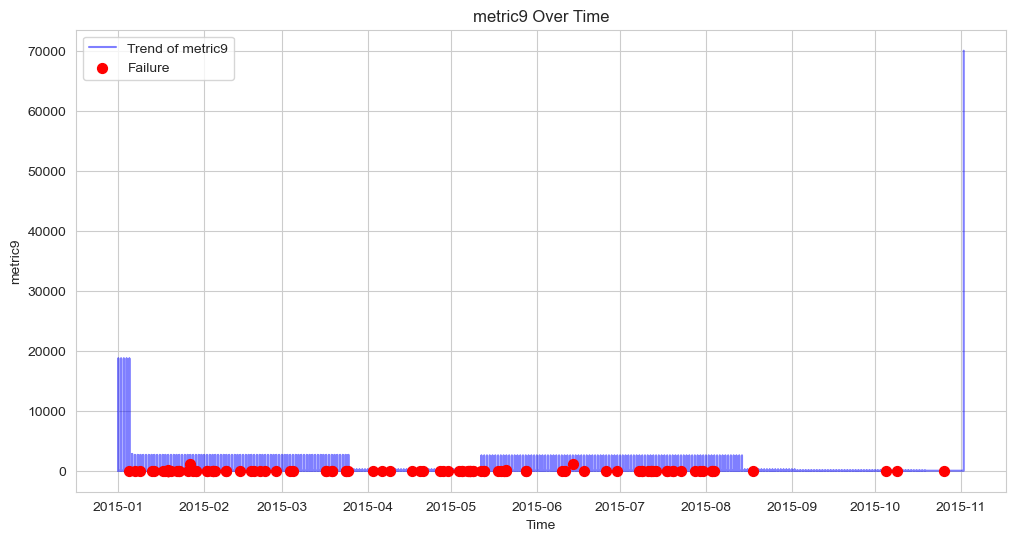

In [9]:
# --- 4. Temporal Trends of Metrics with Failures ---
print("\nVisualizing Temporal Trends of Metrics...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')

for col in metrics:
    plt.figure(figsize=(12, 6))
    # Blue line represents the trend of the metric over time
    plt.plot(df['date'], df[col], linestyle='-', alpha=0.5, label=f"Trend of {col}", color='blue')
    fail_times = df[df[failure_col] == 1]
    # Red dots represent the failure events
    plt.scatter(fail_times['date'], fail_times[col], color='red', s=50, label='Failure', zorder=5)
    plt.title(f"{col} Over Time")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.legend()
    plt.show()


Visualizing Failures per Month...


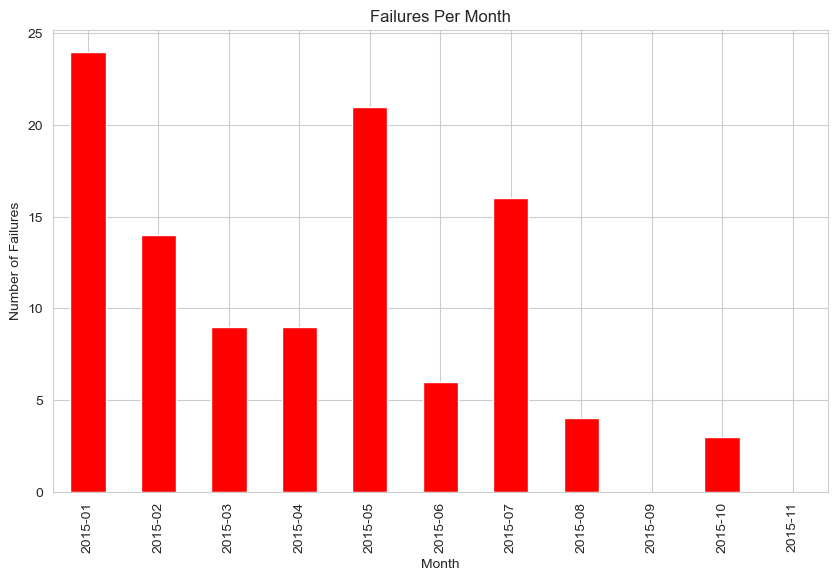

In [10]:
# --- 5. Failures per Month ---
print("\nVisualizing Failures per Month...")
failures_per_month = df.groupby(df['date'].dt.to_period('M'))[failure_col].sum()
# Red bars represent the count of failures
failures_per_month.plot(kind='bar', figsize=(10, 6), color='red')
plt.title("Failures Per Month")
plt.ylabel("Number of Failures")
plt.xlabel("Month")
plt.show()
